# 1. Synthetic SMAD bursts and a classical baseline

We first learn only three coarse trajectory archetypes from the **experimental training fold**. The ported `generateSample.m` logic then adds random-walk variability and separated Gaussian bursts. Validation and test trajectories are independently generated from fixed child seeds.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deeplearning_examples.io import load_data
from burst_detection.classical import detect_classical_bursts
from burst_detection.data import (
    SyntheticBurstConfig, fit_archetype_bank, generate_dataset_splits,
)
from burst_detection.metrics import evaluate_burst_predictions
from burst_detection.visualization import plot_burst_examples

## Fit the background trajectories without leakage

The MATLAB code clusters the complete `Stimulation_100pM_2013.mat` matrix. Here we use the repository's already-fixed training fold and select 100 pM before K-means. This keeps experimental validation and test cells out of synthetic-data design.

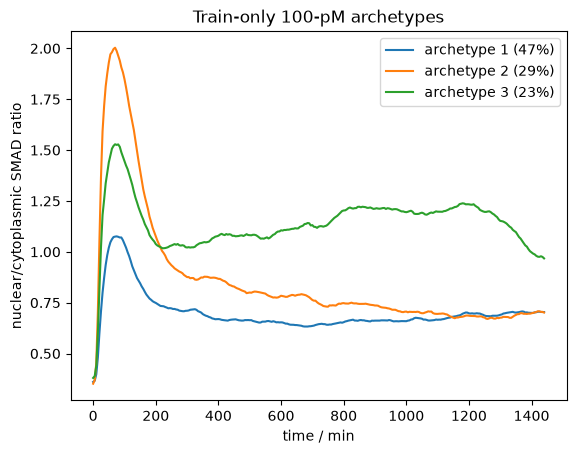

In [6]:
experimental_train, doses, _ = load_data("train")
archetypes = fit_archetype_bank(experimental_train[doses == "100pM"], random_seed=42)

time_minutes = np.arange(experimental_train.shape[1]) * 5
for index, (trajectory, probability) in enumerate(
    zip(archetypes.trajectories, archetypes.probabilities), start=1
):
    plt.plot(time_minutes, trajectory, label=f"archetype {index} ({probability:.0%})")
plt.xlabel("time / min")
plt.ylabel("nuclear/cytoplasmic SMAD ratio")
plt.title("Train-only 100-pM archetypes")
plt.legend();

## Generate fixed folds

The default length is 289 (0 to 1440 minutes at five-minute spacing). The initial stimulus response and all accepted synthetic hills are positive regions; instance IDs remain available for inspecting individual bursts.

In [7]:
config = SyntheticBurstConfig()
splits = generate_dataset_splits(
    train_size=800, validation_size=200, test_size=200,
    archetypes=archetypes, config=config, random_seed=42,
)

summary = pd.DataFrame(
    {
        name: {
            "trajectories": len(split.signals),
            "time points": split.signals.shape[1],
            "positive fraction": split.labels.mean(),
            "mean events/cell": np.mean([len(events) for events in split.events]),
        }
        for name, split in (("train", splits.train), ("validation", splits.validation), ("test", splits.test))
    }
).T
summary

,trajectories,time points,positive fraction,mean events/cell
train,800.0,289.0,0.439901,4.38625
validation,200.0,289.0,0.454429,4.46000
test,200.0,289.0,0.444533,4.48000


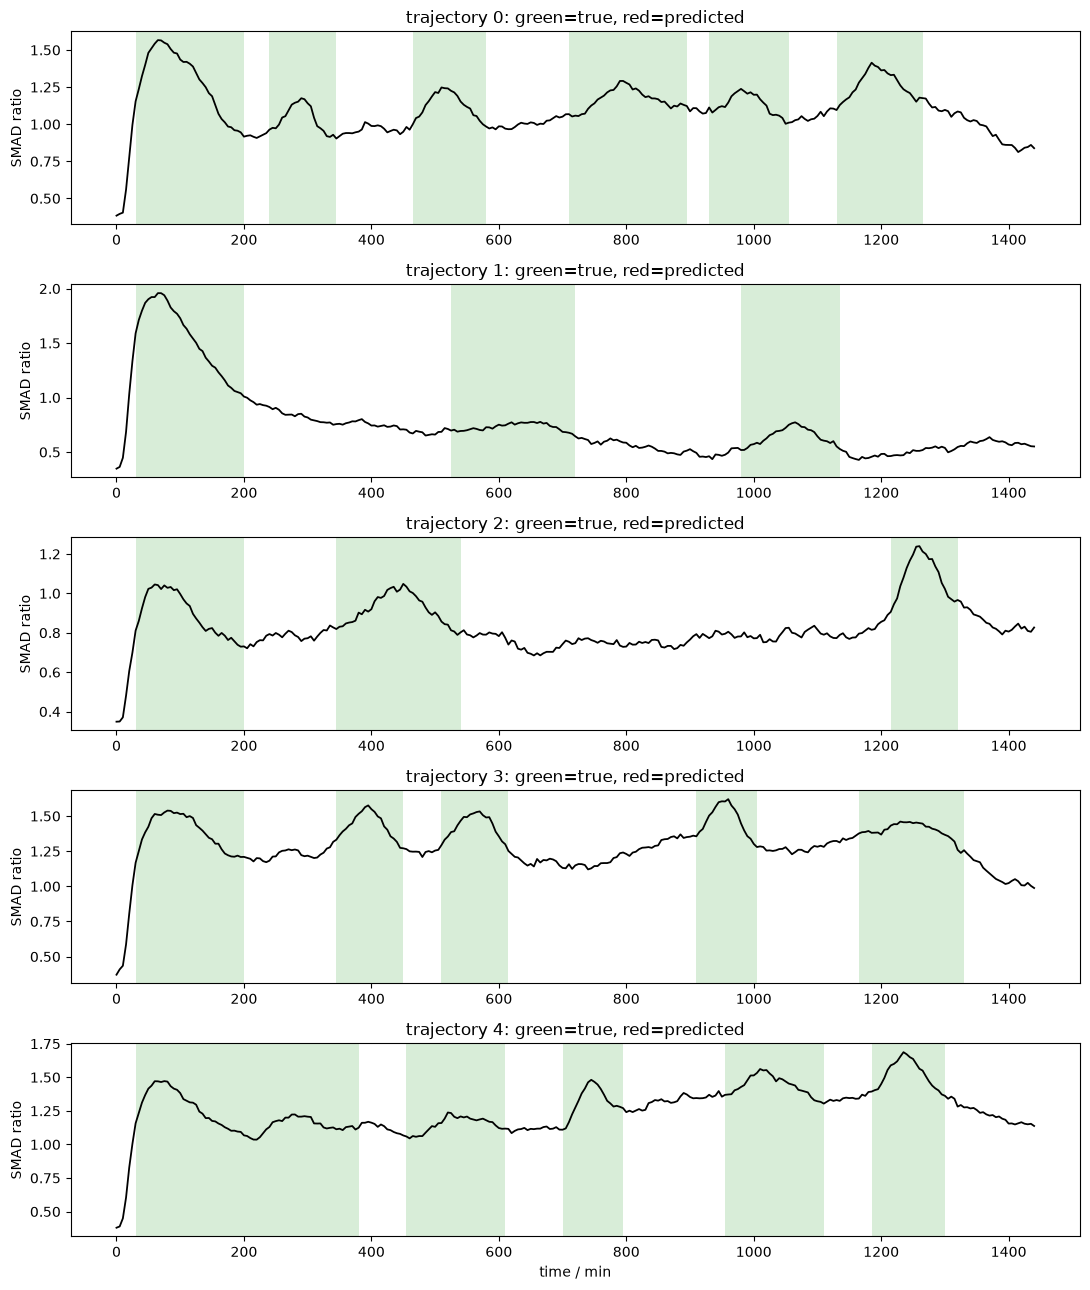

In [8]:
plot_burst_examples(
    splits.train.signals, splits.train.labels,
    time_minutes=splits.train.time_minutes, maximum_examples=5,
);

## Classical detector

The Python comparator follows `burstDetect.m`: smooth small peaks, subtract a slowly varying trend, smooth again, then label supports around prominent peaks. SciPy and MATLAB define peak widths slightly differently, so the result is a faithful algorithmic equivalent rather than bit-identical output. No detector threshold is tuned on test data.

In [9]:
classical_mask = detect_classical_bursts(splits.test.signals)
classical_metrics = evaluate_burst_predictions(
    splits.test.labels, classical_mask.astype(float),
    threshold=0.5, sample_interval_minutes=config.sample_interval_minutes,
)
pd.Series(classical_metrics.to_dict(), name="classical test")

point_precision              0.763648
point_recall                 0.859111
point_f1                     0.808571
average_precision            0.718714
roc_auc                      0.823170
event_precision              0.943287
event_recall                 0.909598
event_f1                     0.926136
true_event_count           896.000000
predicted_event_count      864.000000
matched_event_count        815.000000
burst_count_mae              0.560000
center_time_mae_minutes     15.638037
duration_mae_minutes        41.791411
Name: classical test, dtype: float64

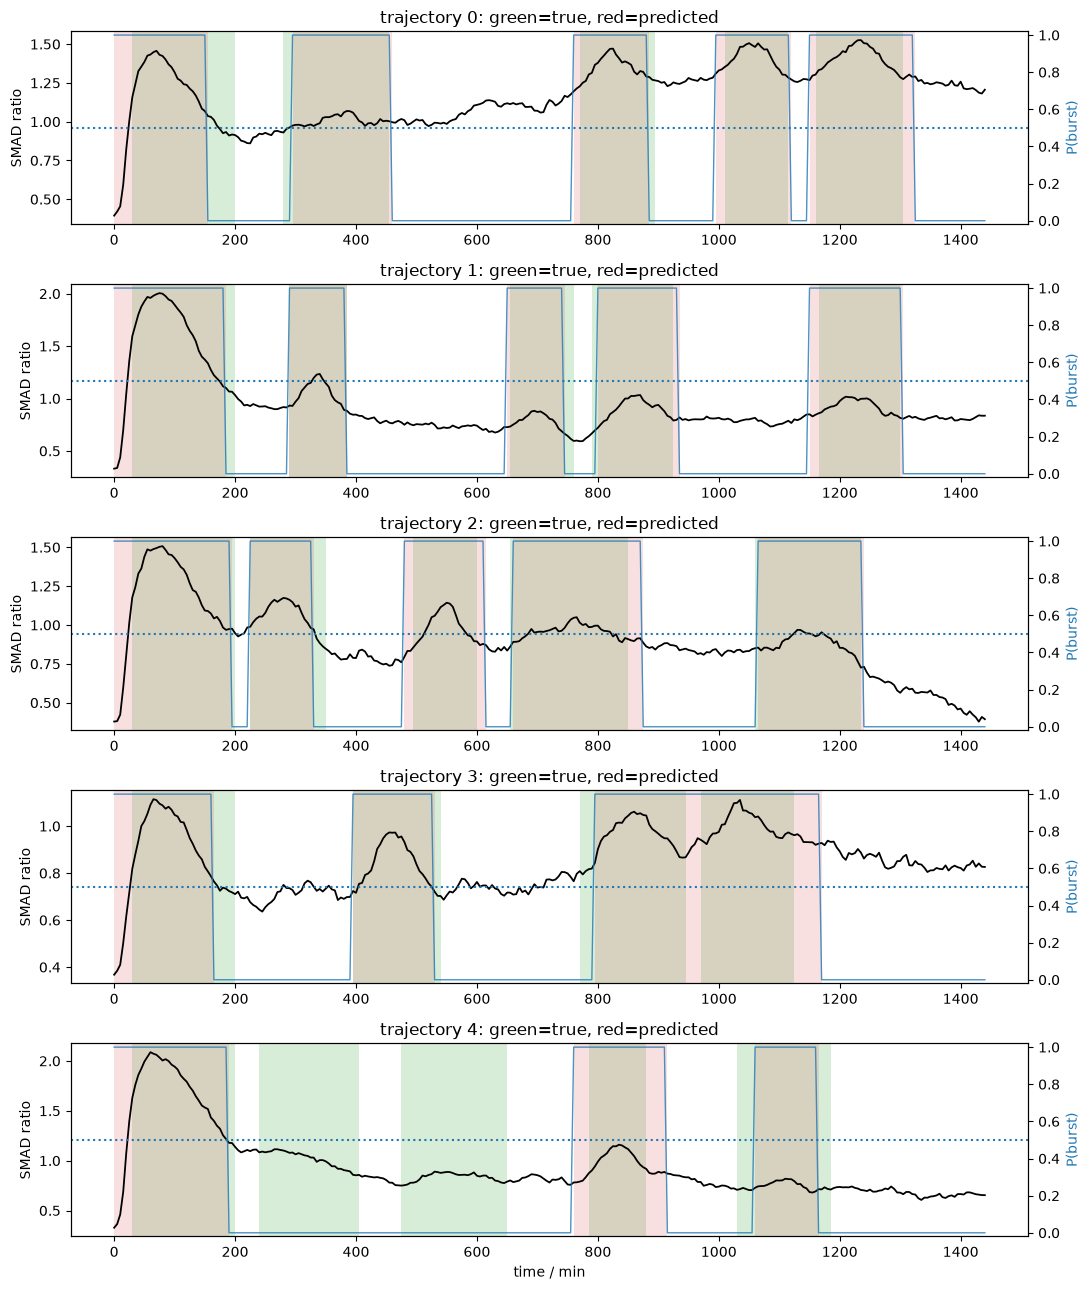

In [10]:
plot_burst_examples(
    splits.test.signals, splits.test.labels,
    probabilities=classical_mask.astype(float), threshold=0.5,
    time_minutes=splits.test.time_minutes, maximum_examples=5,
);

## Interpretation checkpoint

Pointwise scores reward overlap duration, while event scores ask whether each burst was found once. Center and duration errors are calculated only for matched events; burst-count MAE also penalizes missed and extra events. This distinction matters when a broad predicted region overlaps the right signal but merges two biological events.